In [1]:
library(tidyverse)
library(repr)
library(paletteer)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Data and Rates

In [2]:
tl_raw<- read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Tissue_Loss/T1-T4_Avg_Tissue_Loss.csv',show_col_types = FALSE)

In [3]:
tl_raw<-tl_raw %>%
    select(1:14) %>%
    select(-`immune_y/n`,-Height,-MaxDiameter,-Size_Class)
# create colony_id
tl_raw<-tl_raw %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [4]:
head(tl_raw)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Date_DocumentedDisease,Date_DocumentedMortality,062019_TL,052022_TL,122022_TL,colony_id
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,82.5,37.5,25,T1_SSID_1
6/21/2019,CBC30N,1,2,PAST,Healthy,Healthy,97.5,95,97.5,T1_PAST_2
6/21/2019,CBC30N,1,3,SSID,5/21/2022,Diseased,95,95,92.5,T1_SSID_3
10/15/2019,CBC30N,1,4,PSTR,5/21/2022,12/2/2022,97.5,35,0,T1_PSTR_4
6/24/2019,CBC30N,1,5,SSID,5/21/2022,Diseased,97.5,35,27.5,T1_SSID_5
10/15/2019,CBC30N,1,6,PSTR,12/2/2022,9/25/2023,100,100,62.5,T1_PSTR_6


In [5]:
# combine with colony data for health statuses
colony<-read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_ColonyData.csv',show_col_types = FALSE)

In [6]:
colony<-colony %>%
    select(TransectNum,NewTagNum,Species,`062019_Condition`,`102019_Condition`,`052022_Condition`,`122022_Condition`) %>%
    filter(!(TransectNum %in% c('5','6')))
# create colony_id
colony<-colony %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [7]:
head(colony,2)

TransectNum,NewTagNum,Species,062019_Condition,102019_Condition,052022_Condition,122022_Condition,colony_id
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,SSID,Healthy,NA,Diseased,Diseased,T1_SSID_1
1,2,PAST,Healthy,NA,Healthy,Healthy,T1_PAST_2


In [8]:
# merge by colony id 
tl<-tl_raw %>% 
    left_join(colony %>% select(-TransectNum,-NewTagNum,-Species), by = "colony_id")

In [9]:
# select diseased colonies only
conditions <- c('Diseased','Dead')
tl_dis<-tl %>%
    filter(`052022_Condition` %in% conditions | `122022_Condition` %in% conditions)

In [10]:
# pivot
tl_dis_long <- tl_dis %>% 
  pivot_longer(
    cols = matches("^\\d{6}_(Condition|TL)$"),
    names_to = c("Date", ".value"),
    names_pattern = "^(\\d{6})_(Condition|TL)$") %>%
  rename(tissue = TL)

In [11]:
head(tl_dis_long,6)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Date_DocumentedDisease,Date_DocumentedMortality,colony_id,Date,tissue,Condition
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,062019,82.5,Healthy
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,052022,37.5,Diseased
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,122022,25,Diseased
6/21/2019,CBC30N,1,1,SSID,5/21/2022,Diseased,T1_SSID_1,102019,NA,NA
6/21/2019,CBC30N,1,3,SSID,5/21/2022,Diseased,T1_SSID_3,062019,95,Healthy
6/21/2019,CBC30N,1,3,SSID,5/21/2022,Diseased,T1_SSID_3,052022,95,Diseased


In [12]:
# calculate rate of tl for diseased colonies
# change in TL over time
    # collect exact monitoring date
    # calculate number of weeks in between time points
    # calculate change in TL between time points
    # May and Dec: change in TL / number of weeks

In [13]:
# collect exact monitoring date

In [14]:
# add sampling date
samples<-read_csv('/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_samples.csv',show_col_types = FALSE)

In [15]:
samples<-samples %>% 
    select(Month_year,CollectionDate,TransectNum,NewTagNum,Species) %>%
    distinct() %>%
    rename(Date = Month_year) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum))

In [16]:
# remove duplicate collectiondates
samples<-samples%>%distinct(colony_id,Date, .keep_all = TRUE)

In [17]:
tld<-tl_dis_long %>% 
    filter(!(is.na(Condition))) %>%
    left_join(samples %>% select(-TransectNum,-NewTagNum,-Species), by = c("colony_id","Date"))

In [20]:
# add in monitoring date
tld<-tld %>%
    mutate(fulldate = as.Date(CollectionDate,format = "%m/%d/%y"))
# if missing collectiondate,
# grab another fulldate from coral with same timepoint
tld <- tld %>%
  group_by(Date, Transect) %>%
  fill(fulldate, .direction = "downup") %>%
  ungroup()

In [22]:
unique(tld$tissue)

[1] "82.5"    "37.5"    "25"      "95"      "92.5"    "97.5"    "35"     
 [8] "0"       NA        "27.5"    "100"     "62.5"    "15"      "7.5"    
[15] "5"       "2.5"     "70"      "22.5"    "90"      "65"      "77.5"   
[22] "50"      "52.5"    "exclude" "60"      "55"      "32.5"    "67.5"   
[29] "n/a"     "45"      "20"      "10"      "85"      "40"      "57.5"   
[36] "87.5"

In [23]:
tld$tissue <- as.numeric(tld$tissue)
# remove NAs (entries were either NA or 'exclude' already)
tld <- tld %>% filter(!(is.na(tissue)))

Warning message:
“NAs introduced by coercion”


In [24]:
# drop colonies after they die
# id colonies with 0 tissue twice in a row and remove second time point
tld<- tld %>%
  group_by(colony_id) %>%
  arrange(fulldate, .by_group = TRUE) %>%
  mutate(dead_flag = cummax(as.numeric(tissue == 0 & lag(tissue, default = first(tissue)) == 0))) %>%
  filter(dead_flag == 0) %>%
  select(-dead_flag) %>%
  ungroup()

In [25]:
# calculate number of weeks in between time points
tld <- tld %>%
    group_by(colony_id) %>%
    arrange(fulldate, .by_group = TRUE) %>%
    mutate(diff_weeks = as.numeric(difftime(fulldate, lag(fulldate), units = "weeks"))) %>%
# calculate change in TL between time points
    mutate(diff_tl = tissue - lag(tissue)) %>%
    ungroup()

In [26]:
# calculate TL rates
tld<-tld %>%
    mutate(rate_abs = round(diff_tl / diff_weeks,2))

In [80]:
# avg TL rates per spp (2019 -> May, May -> Dec)
ratei<-tld %>%
    filter(Date == "052022") %>%
    group_by(Species) %>%
    summarise(mean_rate_abs1 = round(mean(rate_abs, na.rm = TRUE),2),
             sd_rate_abs1 = sd(rate_abs, na.rm = TRUE)) %>%
    arrange(mean_rate_abs1)

In [81]:
# avg TL rates per spp (May -> Dec)
ratef<-tld %>%
    filter(Date == "122022") %>%
    group_by(Species) %>%
    summarise(mean_rate_abs2 = round(mean(rate_abs, na.rm = TRUE),2),
              sd_rate_abs2 = sd(rate_abs, na.rm = TRUE))%>%
    arrange(mean_rate_abs2)

In [82]:
rates_abs<-left_join(ratei,ratef, by = "Species")

In [30]:
# or use percent change as numerator??
# tristin calculated percent change - got csv from his github: https://github.com/TristinH04/TissueLoss/blob/main/testgraphs/PercentAvg/T1-T4_Avg_Tissue_Loss_perchangeboth.csv
perchange<-read_csv("T1-T4_Avg_Tissue_Loss_perchangeboth.csv",show_col_types =  FALSE)

In [31]:
# keep sctld time points only 
pctd <- perchange %>%
    select(TransectNum,NewTagNum,Species,`062019_TL-052022_TL`,`052022_TL-122022_TL`) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",Species,'_',NewTagNum)) %>%
    rename("052022" = `062019_TL-052022_TL`,
          "122022" = `052022_TL-122022_TL`)

In [32]:
# filter colonies
pctd<-pctd %>%
    filter(colony_id %in% unique(tld$colony_id))

In [33]:
# pivot and merge 
pctd<-pctd %>%
    pivot_longer(cols = c('052022','122022'),
                names_to = "Date",
                values_to = "pctd_tl")
tld<-tld %>%
    left_join(pctd%>%select(-TransectNum,-NewTagNum,-Species), by = c('colony_id','Date'))

In [34]:
# calculate rates based on pct change
tld$pctd_tl <- as.numeric(tld$pctd_tl)
tld <- tld %>%   
    mutate(rate_pctd = round(pctd_tl / diff_weeks,2))

Warning message:
“NAs introduced by coercion”


In [83]:
# avg TL rates per spp (2019 -> May, May -> Dec)
ratei<-tld %>%
    filter(Date == "052022") %>%
    group_by(Species) %>%
    summarise(mean_rate_pctd1 = round(mean(rate_pctd, na.rm = TRUE),2),
             sd_rate_pctd1 = sd(rate_pctd, na.rm = TRUE))

# avg TL rates per spp (May -> Dec)
ratef<-tld %>%
    filter(Date == "122022") %>%
    group_by(Species) %>%
    summarise(mean_rate_pctd2 = round(mean(rate_pctd, na.rm = TRUE),2),
             sd_rate_pctd2 = sd(rate_pctd, na.rm = TRUE))

rates_pctd<-left_join(ratei,ratef, by = "Species")

In [84]:
rates<-left_join(rates_abs,rates_pctd,by = "Species")
rates
# 1 is 2019 - May 2022
# 2 is May 2022 -> Dec 2022

Species,mean_rate_abs1,sd_rate_abs1,mean_rate_abs2,sd_rate_abs2,mean_rate_pctd1,sd_rate_pctd1,mean_rate_pctd2,sd_rate_pctd2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMEA,-0.65,0.01943651,NA,NA,-0.66,0.003333333,NA,NA
MCAV,-0.49,0.18479590,-1.08,0.8355965,-0.50,0.181362568,-2.80,1.2020786
PSTR,-0.48,0.24051247,-1.90,1.1297330,-0.50,0.251899451,-3.20,0.9145636
SSID,-0.31,0.22916553,-0.33,0.4693363,-0.32,0.235824980,-0.74,0.8893243
PAST,-0.27,0.23259407,-0.40,0.9098351,-0.28,0.239937492,-0.41,0.9966736
DLAB,NaN,NA,-0.18,NA,NaN,NA,-0.19,NA
OANN,NaN,NA,-0.18,NA,NaN,NA,-0.18,NA
OFAV,NaN,NA,-0.36,NA,NaN,NA,-0.36,NA


In [39]:
# ok i think it makes more sense to compare rates from May -> Dec 2022 
    #since we don't know when outbreak occurred within the first time frame
# maybe can just compare avg tissue loss between species across initial time frame 
    # and then compare rates may -> dec?


In [40]:
# remove rates from initial timeframe and run ANOVA
    # idk if its better to use pct change or abs rates
    # i would think % change would standardize for initial differences in tissue loss but idk if this makes sense mathematically

### Assess Normality 

In [41]:
tld %>%
    group_by(Species) %>%
    summarise(n = length(unique(colony_id)))

Species,n
<chr>,<int>
DLAB,1
MCAV,18
MMEA,9
OANN,3
OFAV,1
PAST,5
PSTR,18
SSID,22


In [42]:
# remove 2019 from og df
tld2 <- tld %>% filter(!(Date %in% c('062019','102019')))
# remove any colonies with NA rates
tld2<-tld2 %>%
    filter(!(is.na(diff_tl)))

# remove low occurance spp 
tl_stats<-tld2 %>%
    group_by(Species) %>%
    # filter low occurance species
    filter(n() >= 3) %>%
    ungroup()

In [43]:
summary(tl_stats$rate_abs)
summary(tl_stats$rate_pctd)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.5700 -0.6550 -0.4600 -0.5495 -0.1800  0.4500 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-3.5900 -0.6600 -0.6400 -0.8475 -0.2400  0.6900 

In [44]:
# test for normality of response variable (rates)
shapiro.test(tl_stats$rate_abs)
# not normal


	Shapiro-Wilk normality test

data:  tl_stats$rate_abs
W = 0.74538, p-value = 4.486e-12


In [45]:
# install.packages("rstatix")
# install.packages("ggpubr")
library(rstatix)
# library(ggpubr)


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [46]:
# per group?
tl_stats %>%
    group_by(Species) %>%
    rstatix::shapiro_test(rate_abs) %>%
    filter(p < 0.05)
# non normal

Species,variable,statistic,p
<chr>,<chr>,<dbl>,<dbl>
MCAV,rate_abs,0.7478426,6.254932e-05
MMEA,rate_abs,0.7709570,9.474932e-03
PAST,rate_abs,0.8130611,2.875689e-02
PSTR,rate_abs,0.6969085,1.788055e-05
SSID,rate_abs,0.7651106,1.369733e-06


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


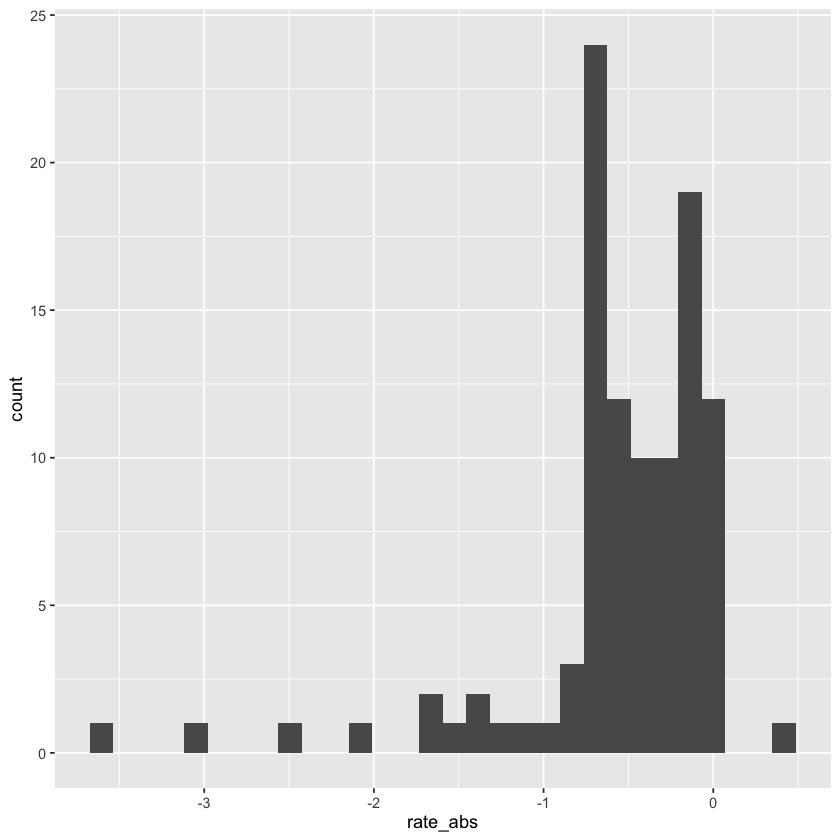

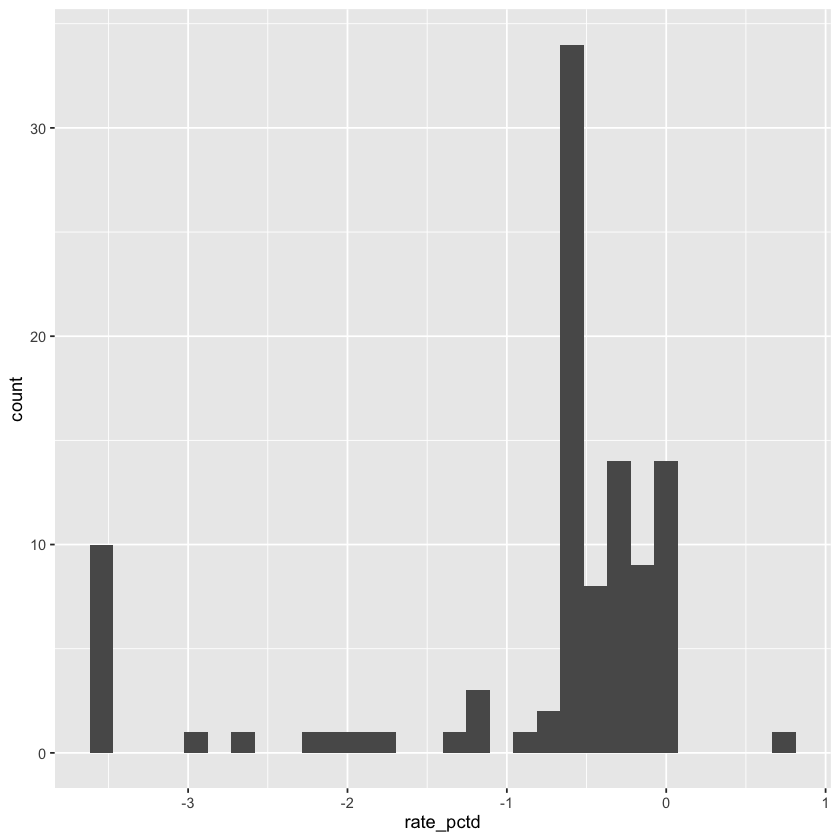

In [47]:
ggplot(tl_stats, aes(x = rate_abs))+
    geom_histogram()
ggplot(tl_stats, aes(x = rate_pctd))+
    geom_histogram()

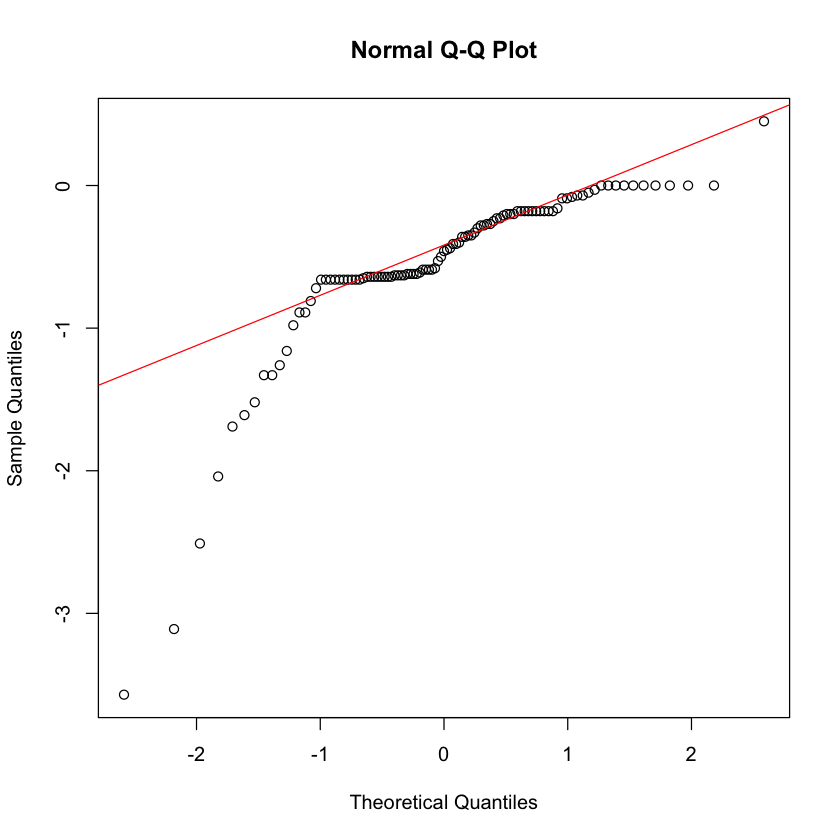

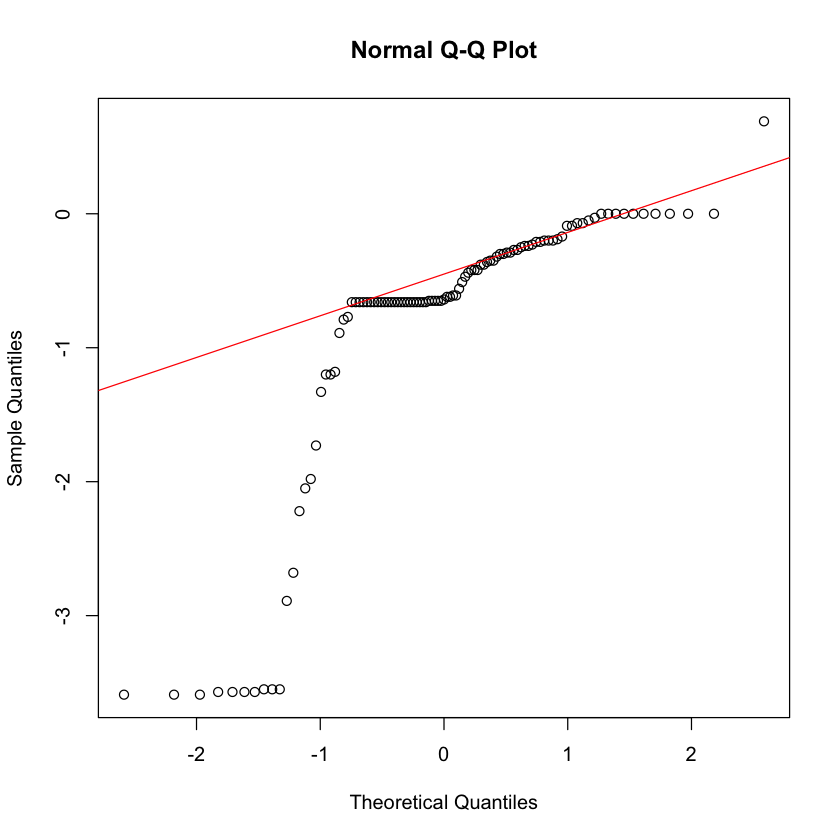

In [48]:
qqnorm(tl_stats$rate_abs)
qqline(tl_stats$rate_abs, col = "red")

qqnorm(tl_stats$rate_pctd)
qqline(tl_stats$rate_pctd, col = "red")

In [49]:
# non normal

In [50]:
summary(tl_stats$pctd_tl)
summary(tl_stats$diff_tl)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-100.00 -100.00  -63.16  -58.92  -21.83   19.23 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-100.00  -95.00  -42.50  -49.42   -7.50   12.50 

In [51]:
# percent change tissue loss (not rate)
tl_stats %>%
    group_by(Species) %>%
    # filter groups with 0 variance (MMEA)
    filter(n_distinct(pctd_tl) > 1) %>%
    rstatix::shapiro_test(pctd_tl) %>%
    filter(p < 0.05)
# not normal

Species,variable,statistic,p
<chr>,<chr>,<dbl>,<dbl>
MCAV,pctd_tl,0.7777189,0.0001721445
PSTR,pctd_tl,0.6327298,0.0000030523
SSID,pctd_tl,0.8671765,0.0002417639


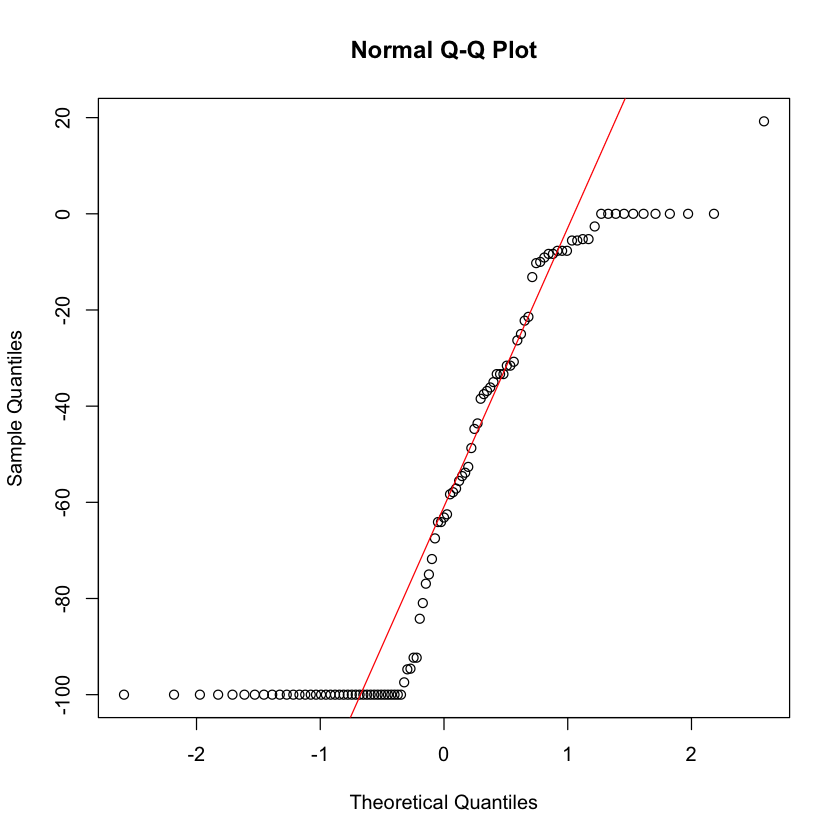

In [52]:
qqnorm(tl_stats$pctd_tl)
qqline(tl_stats$pctd_tl, col = "red")
# not normal but just has big tails

## Stats

In [53]:
# log transform? or use kruskall wallis or glmm instead of anova?? 

In [54]:
head(tl_stats,3)

Date_InitialTag,Transect,TransectNum,NewTagNum,Species,Date_DocumentedDisease,Date_DocumentedMortality,colony_id,Date,tissue,Condition,CollectionDate,fulldate,diff_weeks,diff_tl,rate_abs,pctd_tl,rate_pctd
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6/24/2019,CBC30N,1,14,MCAV,5/21/2022,12/2/2022,T1_MCAV_14,052022,70.0,Diseased,05/21/22,2022-05-21,151.71429,-25,-0.16,-26.31579,-0.17
6/24/2019,CBC30N,1,14,MCAV,5/21/2022,12/2/2022,T1_MCAV_14,122022,0.0,Dead,NA,2022-12-02,27.85714,-70,-2.51,-100.00000,-3.59
6/26/2019,CBC30N,1,15,MCAV,5/21/2022,12/2/2022,T1_MCAV_15,052022,22.5,Diseased,05/21/22,2022-05-21,151.42857,-75,-0.50,-76.92308,-0.51


### Rates

In [55]:
# just use dec 2022 for rates
    # run on both absolute and relative rates

In [85]:
rates

Species,mean_rate_abs1,sd_rate_abs1,mean_rate_abs2,sd_rate_abs2,mean_rate_pctd1,sd_rate_pctd1,mean_rate_pctd2,sd_rate_pctd2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMEA,-0.65,0.01943651,NA,NA,-0.66,0.003333333,NA,NA
MCAV,-0.49,0.18479590,-1.08,0.8355965,-0.50,0.181362568,-2.80,1.2020786
PSTR,-0.48,0.24051247,-1.90,1.1297330,-0.50,0.251899451,-3.20,0.9145636
SSID,-0.31,0.22916553,-0.33,0.4693363,-0.32,0.235824980,-0.74,0.8893243
PAST,-0.27,0.23259407,-0.40,0.9098351,-0.28,0.239937492,-0.41,0.9966736
DLAB,NaN,NA,-0.18,NA,NaN,NA,-0.19,NA
OANN,NaN,NA,-0.18,NA,NaN,NA,-0.18,NA
OFAV,NaN,NA,-0.36,NA,NaN,NA,-0.36,NA


In [86]:
rates_plot<-rates %>%
    pivot_longer(cols = -Species,
             names_to = c("stat", "metric", "timepoint"),
             names_pattern = "(mean|sd)_rate_(abs|pctd)([12])") %>%
    pivot_wider(names_from = stat,
              values_from = value) %>%
    mutate(my = if_else(timepoint =="1","May 2022","Dec 2022"),
          my = factor(my,levels = c("May 2022","Dec 2022")))

rates_plot<-rates_plot %>% 
    filter(!(is.na(mean))) %>%
    # filter low occurance spp
    filter(!(Species %in% c('OFAV','OANN','DLAB')))


In [ ]:
##### DEC ######

In [87]:
tl_dec<-tl_stats %>% filter(Date == "122022")

In [88]:
# absolute rates
tl_dec %>%
    kruskal_test(rate_abs ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_dec %>%
  dunn_test(rate_abs ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_abs,38,14.12432,3,0.002740725,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_abs,MCAV,PAST,8,4,1.4291883,0.1529501250,0.917700750,ns
2,rate_abs,MCAV,PSTR,8,6,-1.0873801,0.2768688414,1.000000000,ns
3,rate_abs,MCAV,SSID,8,20,2.3257825,0.0200301575,0.120180945,ns
4,rate_abs,PAST,PSTR,4,6,-2.2656146,0.0234749932,0.140849959,ns
5,rate_abs,PAST,SSID,4,20,0.1784646,0.8583580889,1.000000000,ns
6,rate_abs,PSTR,SSID,6,20,3.3518409,0.0008027615,0.004816569,**


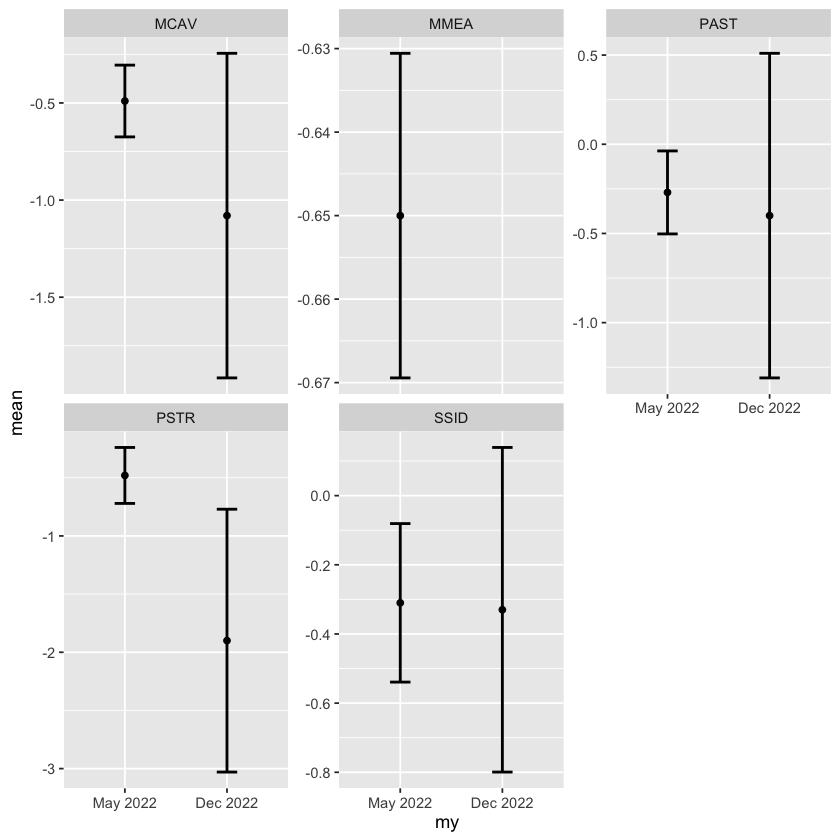

In [89]:
ggplot(rates_plot%>%filter(metric=="abs"),aes(x = my, y = mean))+
    geom_point()+
    geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd),width = 0.2,color = "black",linewidth = 0.8)+
    facet_wrap(~Species,scales = "free_y")

In [90]:
# relative rates
tl_dec %>%
    kruskal_test(rate_pctd ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_dec %>%
  dunn_test(rate_pctd ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_pctd,38,20.49219,3,0.0001341948,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_pctd,MCAV,PAST,8,4,2.4117508,0.0158761271,0.095256763,ns
2,rate_pctd,MCAV,PSTR,8,6,-0.4314235,0.6661604561,1.000000000,ns
3,rate_pctd,MCAV,SSID,8,20,3.3525721,0.0008006437,0.004803862,**
4,rate_pctd,PAST,PSTR,4,6,-2.6489425,0.0080744058,0.048446435,*
5,rate_pctd,PAST,SSID,4,20,-0.1358501,0.8919397541,1.000000000,ns
6,rate_pctd,PSTR,SSID,6,20,3.5135679,0.0004421313,0.002652788,**


In [91]:
# dec relative rates (pos statistic sp1 >)
    # MCAV AND PSTR sig higher rates than SSID
    # PSTR sig higher rate than PAST

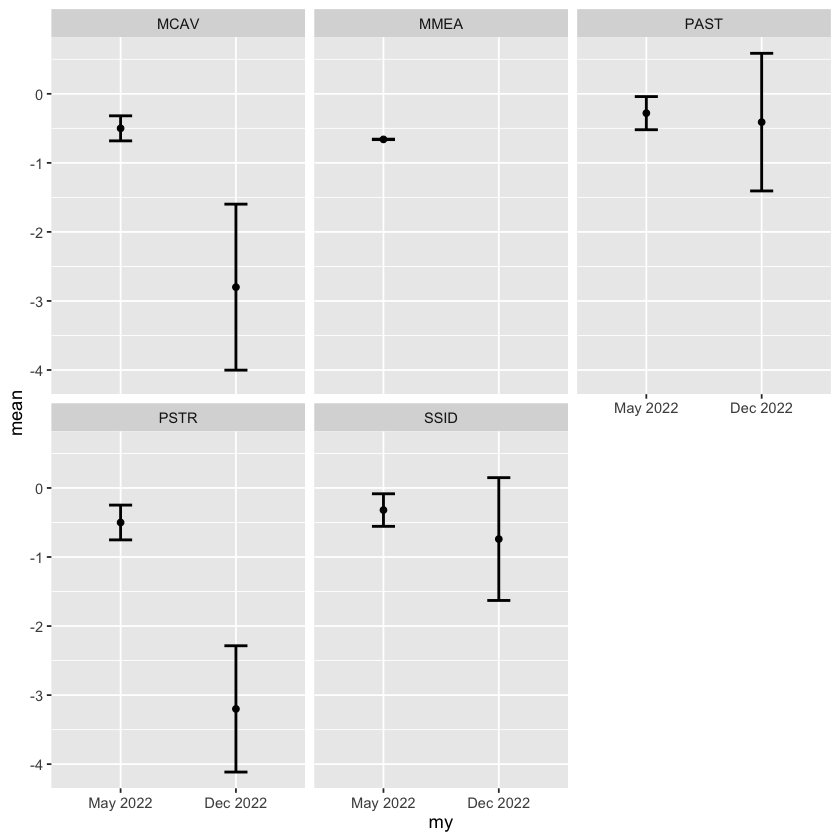

In [92]:
ggplot(rates_plot%>%filter(metric=="pctd"),aes(x = my, y = mean))+
    geom_point()+
    geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd),width = 0.2,color = "black",linewidth = 0.8)+
    facet_wrap(~Species)

In [93]:
# PSTR closely followed by MCAV has highest TL
# SSID and PAST with lowest

# MCAV AND PSTR sig higher rates than SSID
# PSTR sig higher rate than PAST

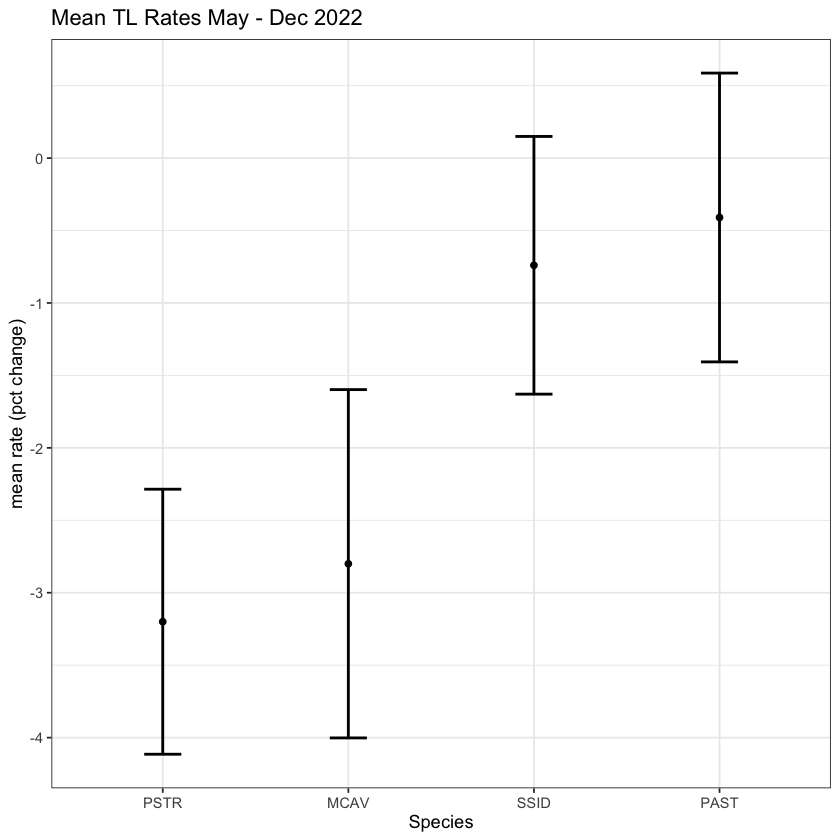

In [97]:
# just look at Dec: mean rates
ggplot(rates_plot%>%filter(metric=="pctd" & my == "Dec 2022"),
       aes(x = fct_reorder(Species,mean), y = mean))+
    geom_point()+
    geom_errorbar(aes(ymin = mean - sd, ymax = mean + sd),width = 0.2,color = "black",linewidth = 0.8)+
    theme_bw()+
    labs(title = "Mean TL Rates May - Dec 2022",
        x = "Species", y = "mean rate (pct change)")

In [ ]:
##### MAY ######

In [69]:
tl_may %>%
    kruskal_test(rate_pctd ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_may %>%
  dunn_test(rate_pctd ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
rate_pctd,65,22.94293,4,0.0001299938,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,rate_pctd,MCAV,MMEA,15,9,-2.380777866,1.727613e-02,0.1727612619,ns
2,rate_pctd,MCAV,PAST,15,5,1.352225526,1.763032e-01,1.0000000000,ns
3,rate_pctd,MCAV,PSTR,15,16,-0.923458928,3.557681e-01,1.0000000000,ns
4,rate_pctd,MCAV,SSID,15,20,2.052296759,4.014083e-02,0.4014083084,ns
5,rate_pctd,MMEA,PAST,9,5,3.051616474,2.276127e-03,0.0227612722,*
6,rate_pctd,MMEA,PSTR,9,16,1.612644299,1.068218e-01,1.0000000000,ns
7,rate_pctd,MMEA,SSID,9,20,4.247320082,2.163428e-05,0.0002163428,***
8,rate_pctd,PAST,PSTR,5,16,-2.010696149,4.435756e-02,0.4435756110,ns
9,rate_pctd,PAST,SSID,5,20,0.005413072,9.956810e-01,1.0000000000,ns


### Tissue Loss

In [63]:
# look at avg tissue loss between species 2019 -> may 2022 ?? 
    # or could do over entire period?? this might make sense but need to recalculate

# i think pct change makes sense here??

In [64]:
# look at avg and median tl per spp 
means<-tl_stats %>%
    group_by(Species,Date)%>%
    summarise(mean_tl = mean(pctd_tl),
             median_tl = median(pctd_tl),
             mean_tissue = mean(tissue)) %>%
    mutate(fulldate = my(Date))
means

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Species and Date.
ℹ Output is grouped by Species.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Species, Date))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


Species,Date,mean_tl,median_tl,mean_tissue,fulldate
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<date>
MCAV,052022,-76.67818,-94.594595,21.83333,2022-05-01
MCAV,122022,-78.49702,-100.000000,10.62500,2022-12-01
MMEA,052022,-100.00000,-100.000000,0.00000,2022-05-01
PAST,052022,-42.03374,-35.000000,56.50000,2022-05-01
PAST,122022,-11.56760,-8.391608,59.37500,2022-12-01
PSTR,052022,-75.85337,-100.000000,23.90625,2022-05-01
PSTR,122022,-89.58333,-100.000000,10.41667,2022-12-01
SSID,052022,-48.38922,-48.684211,49.37500,2022-05-01
SSID,122022,-20.75951,-8.012821,42.50000,2022-12-01


`geom_path()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


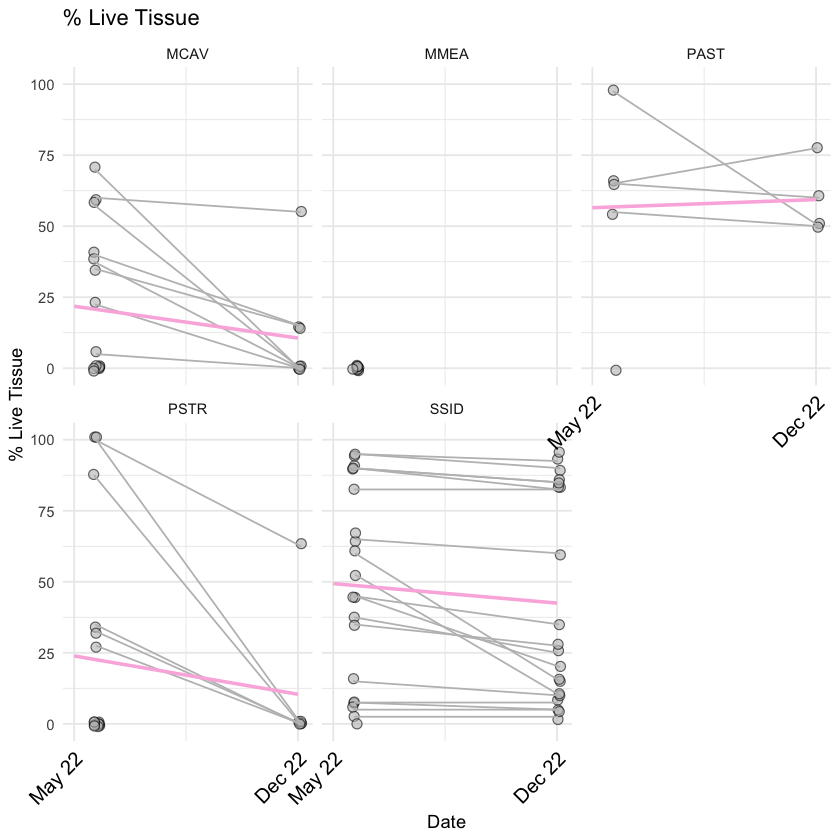

In [65]:
# copied Tristin's code
ggplot(tl_stats, aes(x = fulldate, y = tissue, group = colony_id)) +
  geom_jitter(aes(fill=factor(colony_id)),shape=21, alpha = 0.6, size=2.5, fill = "grey") +
  geom_path( color = "grey") +
  facet_wrap(~Species)+
  geom_line(data = means, aes(x = fulldate, y = mean_tissue, group = 1), color = "#fab6df", linewidth = 1)+
  labs(
    title = "% Live Tissue",
    x = "Date",
    y = "% Live Tissue") +
  theme_minimal() + 
  scale_x_date(breaks = unique(means$fulldate), date_labels = '%b %y') +
  theme(axis.text.x = element_text(colour = "black", hjust = 1, size = 12, angle = 45),
       legend.position = "none") 

In [66]:
tl_stats<-tl_stats %>%
    mutate(my = factor(format(my(Date), "%b %Y"),levels = c('May 2022','Dec 2022')))

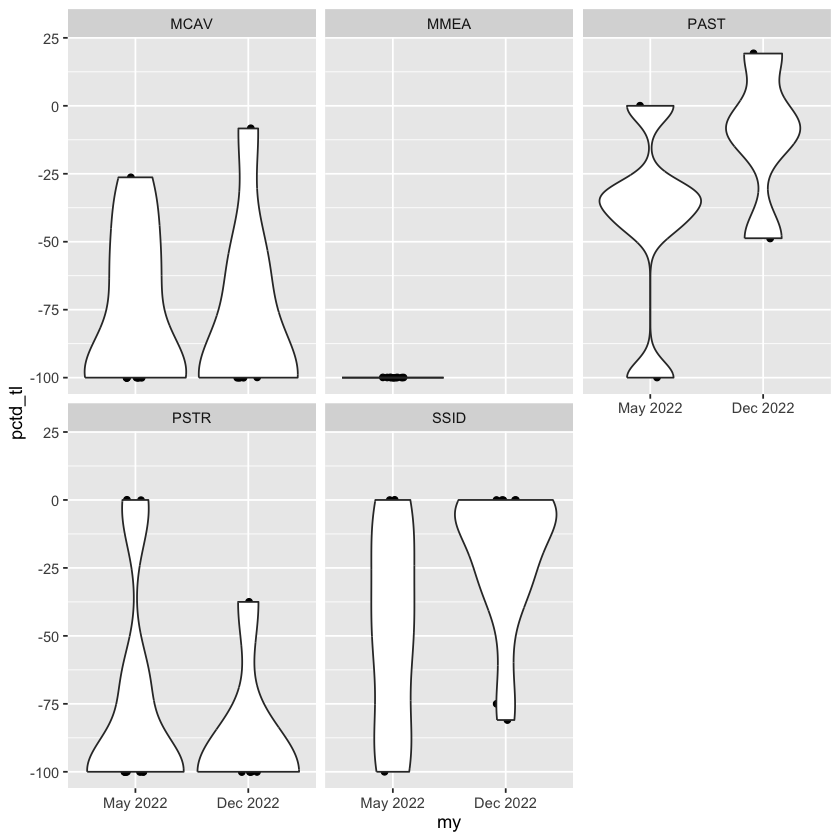

In [67]:
# box plot of pctd per species
ggplot(tl_stats, aes(x = my, y = pctd_tl)) +
    geom_jitter(width = 0.1, height = 0.1)+
    geom_violin()+
    facet_wrap(~Species)

In [ ]:
##### MAY ######

In [68]:
# first look at may
tl_may <- tl_stats %>%
    filter(Date == "052022")

In [99]:
tl_may %>%
    kruskal_test(pctd_tl ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

tl_may %>%
  dunn_test(pctd_tl ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
pctd_tl,65,22.73266,4,0.0001431879,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,pctd_tl,MCAV,MMEA,15,9,-1.97946351,4.776384e-02,0.4776384407,ns
2,pctd_tl,MCAV,PAST,15,5,1.70522437,8.815259e-02,0.8815258610,ns
3,pctd_tl,MCAV,PSTR,15,16,-0.33216259,7.397665e-01,1.0000000000,ns
4,pctd_tl,MCAV,SSID,15,20,2.50136108,1.237170e-02,0.1237169701,ns
5,pctd_tl,MMEA,PAST,9,5,3.07506476,2.104568e-03,0.0210456848,*
6,pctd_tl,MMEA,PSTR,9,16,1.71656795,8.605814e-02,0.8605814314,ns
7,pctd_tl,MMEA,SSID,9,20,4.20789592,2.577595e-05,0.0002577595,***
8,pctd_tl,PAST,PSTR,5,16,-1.95170750,5.097294e-02,0.5097294165,ns
9,pctd_tl,PAST,SSID,5,20,-0.05239324,9.582154e-01,1.0000000000,ns


In [ ]:
# in may,
    # MMEA had sig higher relative TL than PAST and SSID
    # PSTR had sig higher relative TL than SSID

In [ ]:
###### TOTAL TL: all time points #####

In [70]:
# try to recalculate total tissue loss over the entire period 
    # 2019 - last known live time point for each colony

In [71]:
# extract Species, colony id, tl, condition, date
total_tl<-tld %>%
    select(colony_id,Species,Transect,Date,fulldate,tissue,Condition)

In [72]:
# subtract tissue from last live time point - first time point
    # both time points vary for each colony so add labels

In [73]:
# add labels for first and last time points for each colony - all else is NA
total_tl<-total_tl %>%
    group_by(colony_id) %>%
    arrange(fulldate, .by_group = TRUE) %>%
    mutate(timepoint = case_when(
        row_number() == 1 ~ "First",
        row_number() == n() ~ "Last",
        TRUE ~ NA)) %>%
    ungroup()

In [101]:
# subtract tissue from last live time point - first time point
total_long<-total_tl %>%
    filter(!(is.na(timepoint))) %>%
    select(colony_id, Species, timepoint, tissue) %>%
    pivot_wider(names_from = timepoint, 
                values_from = tissue) %>%
    # total tissue loss over whole time period for each colony
    # and pct diff TL over whole time period for each colony
    mutate(diff_tl = Last - First,
          pctd_tl = (Last-First)/First*100) %>%
    filter(!(is.na(diff_tl))) # some colonies that were tagged in dec 2022 end up w/ na
head(total_long)

colony_id,Species,First,Last,diff_tl,pctd_tl
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
T1_DLAB_27,DLAB,97.5,92.5,-5.0,-5.128205
T1_MCAV_14,MCAV,95.0,0.0,-95.0,-100.000000
T1_MCAV_15,MCAV,97.5,0.0,-97.5,-100.000000
T1_MCAV_329,MCAV,97.5,0.0,-97.5,-100.000000
T1_MCAV_333,MCAV,100.0,0.0,-100.0,-100.000000
T1_MCAV_342,MCAV,97.5,0.0,-97.5,-100.000000


In [102]:
# remove low occurance spp 
total_long<-total_long %>%
    group_by(Species) %>%
    filter(n() >= 3) %>%
    ungroup()

In [104]:
# compare spp total tl
total_long %>%
    kruskal_test(pctd_tl ~ Species) %>%
    mutate(sig = if_else(p<0.05,'YES','NO'))

total_long %>%
  dunn_test(pctd_tl ~ Species, p.adjust.method = "bonferroni")

.y.,n,statistic,df,p,method,sig
<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
pctd_tl,67,42.39868,4,1.379059e-08,Kruskal-Wallis,YES


,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,pctd_tl,MCAV,MMEA,15,9,-0.7942393,4.270561e-01,1.000000e+00,ns
2,pctd_tl,MCAV,PAST,15,5,2.5060433,1.220907e-02,1.220907e-01,ns
3,pctd_tl,MCAV,PSTR,15,16,-0.5813774,5.609861e-01,1.000000e+00,ns
4,pctd_tl,MCAV,SSID,15,22,4.4241995,9.680055e-06,9.680055e-05,****
5,pctd_tl,MMEA,PAST,9,5,2.9205337,3.494324e-03,3.494324e-02,*
6,pctd_tl,MMEA,PSTR,9,16,0.3022440,7.624661e-01,1.000000e+00,ns
7,pctd_tl,MMEA,SSID,9,22,4.5902867,4.426376e-06,4.426376e-05,****
8,pctd_tl,PAST,PSTR,5,16,-2.9336744,3.349754e-03,3.349754e-02,*
9,pctd_tl,PAST,SSID,5,22,0.3780650,7.053823e-01,1.000000e+00,ns


In [ ]:
# overall differences - relative change in live tissue 
    # MMEA sig greater than PAST and SSID
    # MCAV sig greater than SSID 
    # PSTR sig greater than SSID and PAST

## GLMM ?